### V2

Gonna be using LK equation's from a Kathy Ludge paper and the parameters they've used. 

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np      
from scipy.integrate import complex_ode

from tasks import make_static_sin_task
from encoding_masking import build_masked_input, compute_tdm_params
from Reservoirs.ELM_static import run_elm_static, ELMStaticParams
from readout import split_states_targets, fit_ridge_readout, predict_readout
from metrics import mse, nrmse

In [2]:
L = 1000
N = 50

#reservoir parameters:
p = 0.05 #normalised injection current
eta = 0.01 #input strength 
alpha = 0 #linewidth enhancemenet factor
phi = 0.0 #phase shift
TLk = 10
kappa = 10**8*0
D_noise = 10**-7

xi = 0 #for now, this is time dependant and represents Gaussian noise.

task_seed = 0
mask_seed = 42


#g = 1.0
ridge_alpha = 1e-4
split = 0.8

theta = 22
dt = 0.1

TDM_parameters = compute_tdm_params(N, theta, dt)

tap_stride = TDM_parameters.tap_stride
Nd_loop = TDM_parameters.Nd_loop
print(TDM_parameters)

TDMParams(N=50, theta=22, dt=0.1, T=1100, tau=1111.0, Nd_loop=11000, Nd_delay=11110, tap_stride=220)


In [3]:
task = make_static_sin_task(L=L, seed=task_seed)
x, y = task.x, task.y


In [4]:
x_norm, mask, V = build_masked_input(x, N=N, rng=mask_seed) # V is really the output only care about here.

In [5]:
def expand_virtual_nodes(V, tap_stride, Nd):

    L, N = V.shape
    #Nd = N * tap_stride

    Vs = np.zeros(L * Nd)

    for l in range(L):
        for n in range(N):
            for step in range(n * tap_stride, (n + 1) * tap_stride):
                Vs[step + l * Nd] = V[l, n]

    return Vs

In [6]:
xpandedV = expand_virtual_nodes(V, tap_stride, Nd_loop)

print(xpandedV.shape)

(11000000,)


In [7]:
print(xpandedV[0])
print(xpandedV[100])
print(xpandedV[200])
print(xpandedV[300])
#

0.32650105571954696
0.32650105571954696
0.32650105571954696
0.185145234253223


In [8]:
print(V.shape)
print(V[0])

(1000, 50)
[0.32650106 0.18514523 0.36220807 0.29419164 0.03972965 0.41157599
 0.32109435 0.33160904 0.05404601 0.18999979 0.15642483 0.39096503
 0.2716209  0.34709017 0.18705869 0.09586291 0.23395711 0.02692194
 0.34914444 0.26647391 0.31980685 0.14956031 0.40949861 0.37677203
 0.32836882 0.08211027 0.1968909  0.01847905 0.06508856 0.28815099
 0.31418532 0.4081536  0.13745267 0.15628211 0.19808679 0.07993038
 0.05480868 0.20068085 0.09572397 0.28256769 0.18441688 0.35127358
 0.2954138  0.13177497 0.35109707 0.33949785 0.16346161 0.12163408
 0.28791752 0.05895597]


In [9]:
def ODEs(E, n, E_delay, v_slot, alpha, kappa, phi, p, eta, D_noise, xi, Tlk):
  
  
    I = abs(E)**2  

   # dEdt = (1.0 + 1j*alpha) * E - I * E + kappa * E_delay * np.exp(1j*phi)
    #dEdt = ((1.0 + 1j*alpha) * E*n ) - (I * E) + (kappa * E_delay * np.exp(1j*phi))
    
    dEdt = ((1.0 + 1j*alpha) * n * E) + (kappa * (np.exp(1j*phi)) * E_delay) + D_noise*xi

   

    dndt = (1/Tlk)*(p + (eta * v_slot) - n -((2*n + 1)*I))

    return dEdt, dndt


In [10]:
def rk4_step(E, n, E_delay, v_slot, dt, alpha, kappa, phi, p, eta, D_noise, xi, Tlk):
    
   # One RK4 step. v should be v over tap_stride duration. 
 
    # k1
    k1_E, k1_n = ODEs(E, n, E_delay, v_slot, alpha, kappa, phi, p, eta, D_noise, xi, Tlk)

    # k2
    E2 = E + 0.5 * dt * k1_E
    n2 = n + 0.5 * dt * k1_n
    k2_E, k2_n = ODEs(E2, n2, E_delay, v_slot, alpha, kappa, phi, p, eta, D_noise, xi, Tlk)

    # k3
    E3 = E + 0.5 * dt * k2_E
    n3 = n + 0.5 * dt * k2_n
    k3_E, k3_n = ODEs(E3, n3, E_delay, v_slot, alpha, kappa, phi, p, eta, D_noise, xi, Tlk)

    # k4
    E4 = E + dt * k3_E
    n4 = n + dt * k3_n
    k4_E, k4_n = ODEs(E4, n4, E_delay, v_slot, alpha, kappa, phi, p, eta, D_noise, xi, Tlk)


    E_next = E + (dt/6.0) * (k1_E + 2*k2_E + 2*k3_E + k4_E)
    n_next = n + (dt/6.0) * (k1_n + 2*k2_n + 2*k3_n + k4_n)

    return E_next, n_next


In [11]:
def simulate_lk(Vs, dt, Nd_delay, *, alpha, kappa, phi, p, eta, D_noise, xi, Tlk, E0=1e-3+0j, n0=0.0):
    Vs = np.asarray(Vs, dtype=float)
    T_steps = Vs.size

    E_hist = np.zeros(T_steps, dtype=np.complex128)
    n_hist = np.zeros(T_steps, dtype=float)

    # delay buffer holds E(t - tau)
    delay_buf = np.full(Nd_delay, E0, dtype=np.complex128)
    di = 0 #Index pointer for delay buffer

    E, n = E0, n0
    for t in range(T_steps):
        v_slot = float(Vs[t])
        E_delay = delay_buf[di]

        E, n = rk4_step(E, n, E_delay, v_slot, dt, alpha, kappa, phi, p, eta, D_noise, xi, Tlk)

        E_hist[t] = E
        n_hist[t] = n

        delay_buf[di] = E
        di = (di + 1) % Nd_delay

    return E_hist, n_hist

def simulate_lk_mini(Vs, dt, Nd_delay, *, alpha, kappa, phi, p, eta, D_noise, xi, Tlk, N_of_thetas, tap_stride, E0=1e-3+0j, n0=0.0):
    Vs = np.asarray(Vs, dtype=float)
    T_steps = N_of_thetas * tap_stride

    if len(Vs) < T_steps:
        raise ValueError("Vs is shorter than N_of_thetas * tap_stride")

    E_hist = np.zeros(T_steps, dtype=np.complex128)
    n_hist = np.zeros(T_steps, dtype=float)

    delay_buf = np.full(Nd_delay, E0, dtype=np.complex128)
    di = 0

    E, n = E0, n0

    for t in range(T_steps):
        v_slot = float(Vs[t])
        E_delay = delay_buf[di]

        E, n = rk4_step(
            E, n, E_delay, v_slot, dt,
            alpha, kappa, phi, p, eta, D_noise, xi, Tlk
        )

        E_hist[t] = E
        n_hist[t] = n

        delay_buf[di] = E
        di = (di + 1) % Nd_delay

    return E_hist, n_hist


def extract_R_from_E(E_hist, L, N, tap_stride, Nd_loop):
    R = np.zeros((L, N), dtype=float)
    for l in range(L):
        base = l * Nd_loop
        for n in range(N):
            t_idx = base + (n + 1) * tap_stride - 1  # end of slot
            R[l, n] = np.abs(E_hist[t_idx])**2
    return R


def intensities_after_theta_times(E_hist, N_of_thetas, tap_stride):
    R_array = np.zeros(N_of_thetas, dtype=float)
    
    for k in range(N_of_thetas):
        t = k * tap_stride
        R_array[k] = np.abs(E_hist[t])**2

    return R_array


In [12]:
tap_stride = TDM_parameters.tap_stride  
Nd_delay = TDM_parameters.Nd_delay    
tau = TDM_parameters.tau


Vs = expand_virtual_nodes(V, tap_stride=tap_stride, Nd=Nd_loop)  
E_hist, n_hist = simulate_lk(Vs, dt, Nd_delay, alpha=alpha, kappa=kappa, phi=phi, p=p, eta=eta, D_noise=D_noise, xi=xi, Tlk=10, E0=1e-3+0j, n0=0.0)
R = extract_R_from_E(E_hist, L=L, N=N, tap_stride=tap_stride, Nd_loop=Nd_loop)
print("R shape:", R.shape)  # should be (L, N)
print(Vs)



R shape: (1000, 50)
[ 0.32650106  0.32650106  0.32650106 ... -0.06722717 -0.06722717
 -0.06722717]


MSE: 0.45312882181149333
NRMSE: 0.9265665511018781


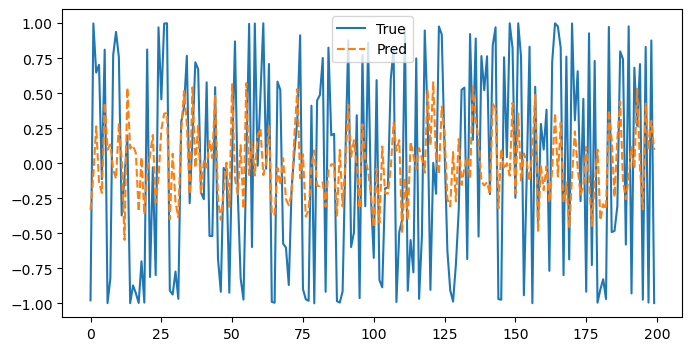

In [19]:
s = split_states_targets(R, y, split=split)
model = fit_ridge_readout(s.R_train, s.y_train, alpha=ridge_alpha, fit_intercept=False)
y_pred = predict_readout(model, s.R_test)

print("MSE:", mse(s.y_test, y_pred))
print("NRMSE:", nrmse(s.y_test, y_pred))

plt.figure(figsize=(8,4))
plt.plot(s.y_test[:2000], label="True")
plt.plot(y_pred[:2000], "--", label="Pred")
plt.legend()
plt.show()

In [14]:
#plt.semilogy(R[1,:])
#plt.show()



In [15]:
#N_of_thetas = 70*5
N_of_thetas = 50
E_hist1, n_hist1 = simulate_lk_mini(Vs, dt, Nd_delay, alpha=alpha, kappa=kappa, phi=phi, p=p, eta=0, D_noise=D_noise, xi=xi, Tlk=50, E0=1e-3+0j, n0=0.0, N_of_thetas=N_of_thetas, tap_stride=tap_stride)
number_of_points = N_of_thetas*tap_stride
#R_mini = extract_R_from_E(E_hist1, L=L, N=, tap_stride=tap_stride, Nd_loop=Nd_loop)
#print("R shape:", R_mini.shape)  # should be (L, N)

R_mini_array = intensities_after_theta_times(E_hist1, N_of_thetas=N_of_thetas, tap_stride=tap_stride)
print("R_mini shape:", R_mini_array.shape)


R_mini shape: (50,)


In [16]:
print(R_mini_array)

[1.00000999e-06 1.52766257e-06 4.39174663e-06 1.89698434e-05
 1.06468124e-04 7.05819942e-04 5.13078797e-03 3.54455937e-02
 1.27816924e-01 9.99605568e-02 4.27793224e-02 2.73484469e-02
 2.88343321e-02 4.06332812e-02 5.71389773e-02 6.35127218e-02
 5.62065642e-02 4.77247178e-02 4.45205386e-02 4.61212624e-02
 4.98074119e-02 5.23531430e-02 5.22211636e-02 5.05313909e-02
 4.91437820e-02 4.88962151e-02 4.95130789e-02 5.02419529e-02
 5.05228561e-02 5.03232717e-02 4.99715418e-02 4.97759328e-02
 4.98135196e-02 4.99684396e-02 5.00865039e-02 5.00980342e-02
 5.00356794e-02 4.99720435e-02 4.99526234e-02 4.99741590e-02
 5.00057218e-02 5.00211326e-02 5.00156715e-02 5.00012146e-02
 4.99914471e-02 4.99914794e-02 4.99975285e-02 5.00030060e-02
 5.00042547e-02 5.00020132e-02]


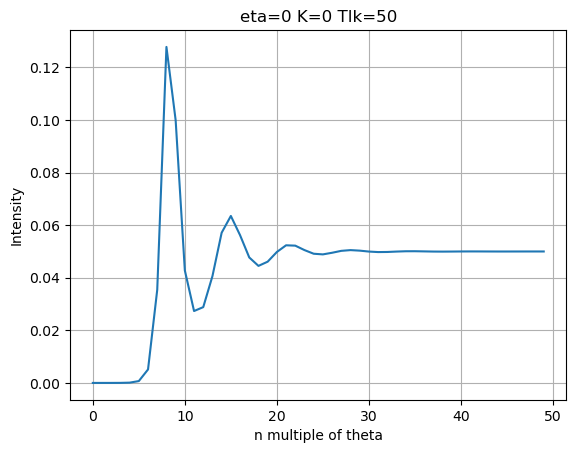

In [17]:
plt.plot(R_mini_array)
plt.xlabel("n multiple of theta")
plt.ylabel("Intensity")
plt.title("eta=0 K=0 Tlk=50")
plt.grid(True)
plt.show()